In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

## Black-hole binary formation channels with gaussian mixtures.

Many problems in astrophysics give rise to data with multiple modes. This is typically because different processes physical processes contribute to the observed dataset. 

For instance, one of the most outstanding question in gravitational-wave astrophysics is the formation channel of binary black holes. Leading scenarions include the evolution of isolated binaries in the galactic field and the dynamica assembly of sources in dense environments like globular clusters.


Right now, state-of-the-art analyses seems to say that many channels are all at play. There is a plot by [Zevin et al (2020)](https://arxiv.org/abs/2011.10057) where they consider 5 possibilities for the formation of black hole binaries: common envelope (CE), chemically omogenous stars (CHE), globular clusters (GC), nuclear star clusters (NSC) and stable mass transfer (SMT). 


Some events form in different astrophysical environments than others. **You want to figure out how many of formation channels are at play.**


The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of $N$ gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$ and weight $\alpha_j$:

$p(x_i|\theta) = \sum_{j=1}^N \alpha_j \mathcal{N}(x_i| \mu_j,\sigma_j) $

This depends on $3N-1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability.)

#### Tasks

**1.** Load this file (`np.load`) and complete a quick exploration of the data. How many modes do you think you see?


In [23]:
data = np.load('../solutions/formationchannels.npy')
print(np.shape(data))

(2950, 1)


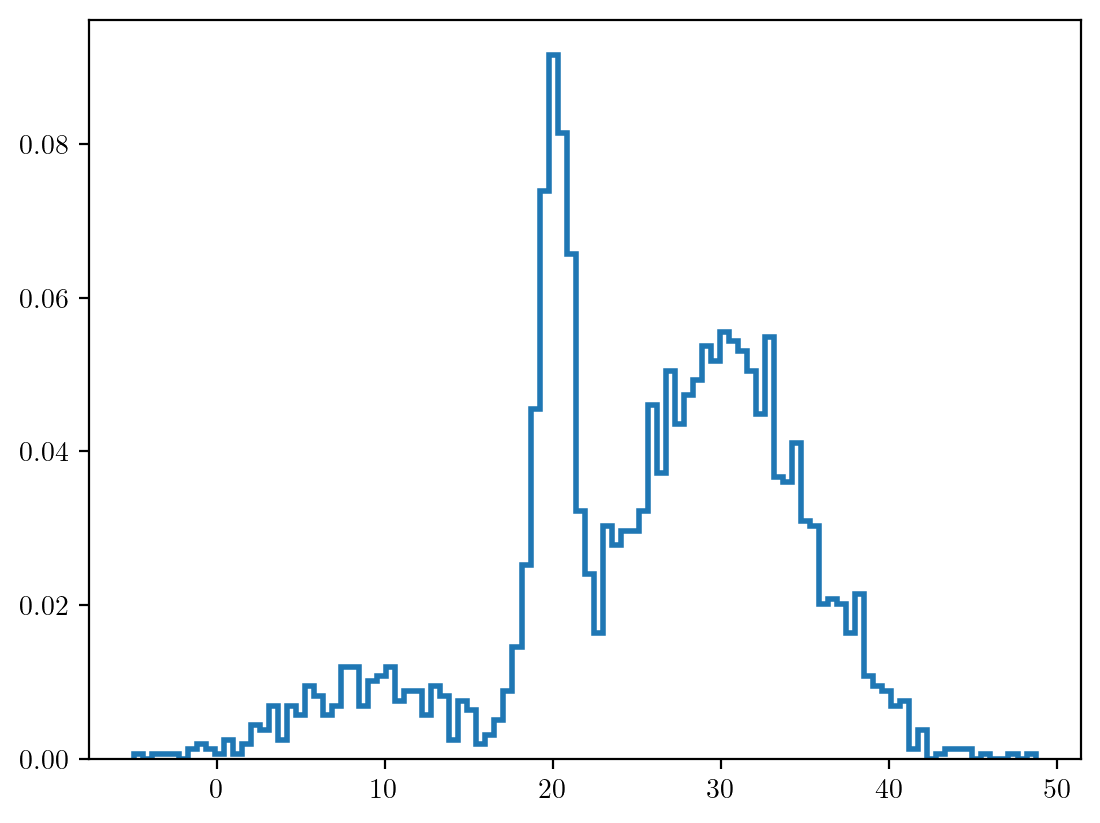

In [60]:
_ = plt.hist(data[:], bins = 100, density=True, histtype= 'step', lw = 2)


**2.** We'll use `sklearn.mixture.GaussianMixture`. You first need to define the model (instance of a class), and then train it on the data using the `fit` method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

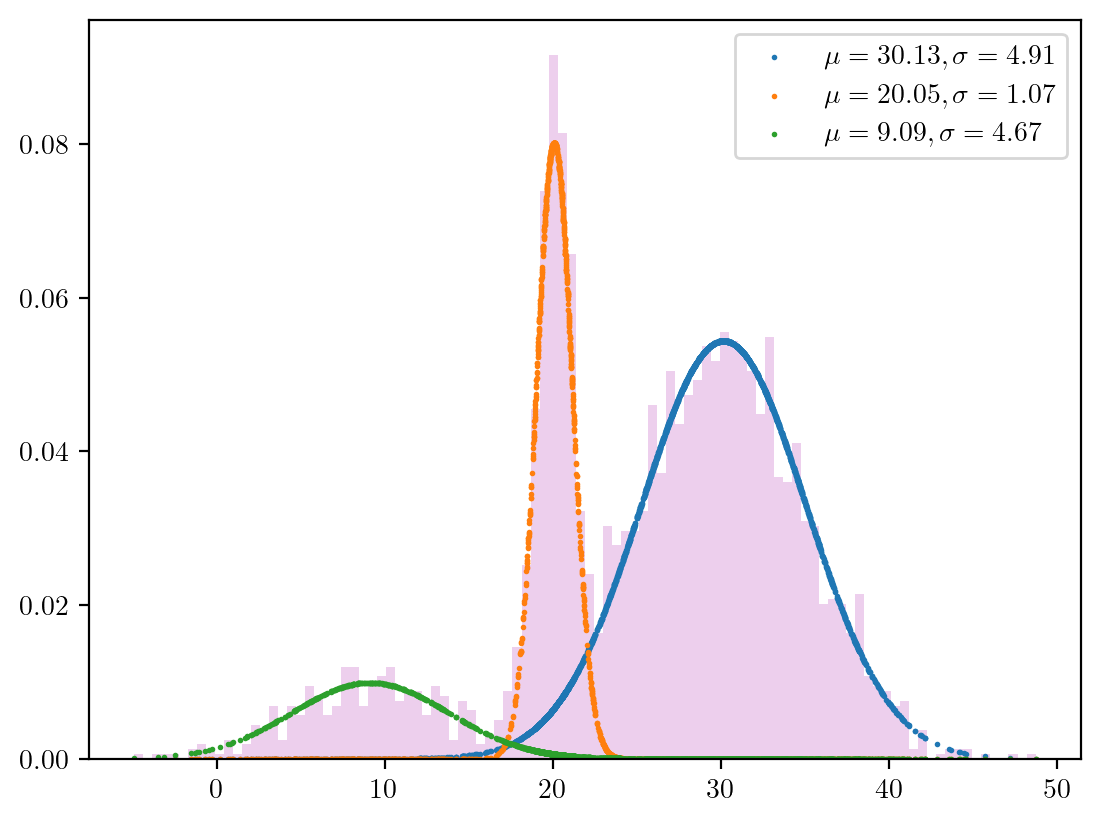

In [69]:
n_comp = 3
model = GaussianMixture(n_comp, random_state=42)
fit = model.fit(data)

means = fit.means_
cov = fit.covariances_
weights = fit.weights_

_ = plt.hist(data[:], bins = 100, density=True, alpha = 0.5, color='plum')

for i in range(n_comp):
    mu = means[i][0]
    sigma = np.sqrt(cov[i])[0][0]
    g = norm(mu, sigma).pdf(data)*weights[i]
    plt.scatter(data, g, s = 1., label = rf'$\mu={mu:.2f}, \sigma={sigma:.2f}$')
plt.legend()


**3.** Complete the fit 10 times with $N=1,...,10$ Gaussians. 

Note: `sklearn` by default will use the so-called [Expectation-Maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm), which is one of the many great things in data science we don't have time to study in this class.

**4.** For each of these fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

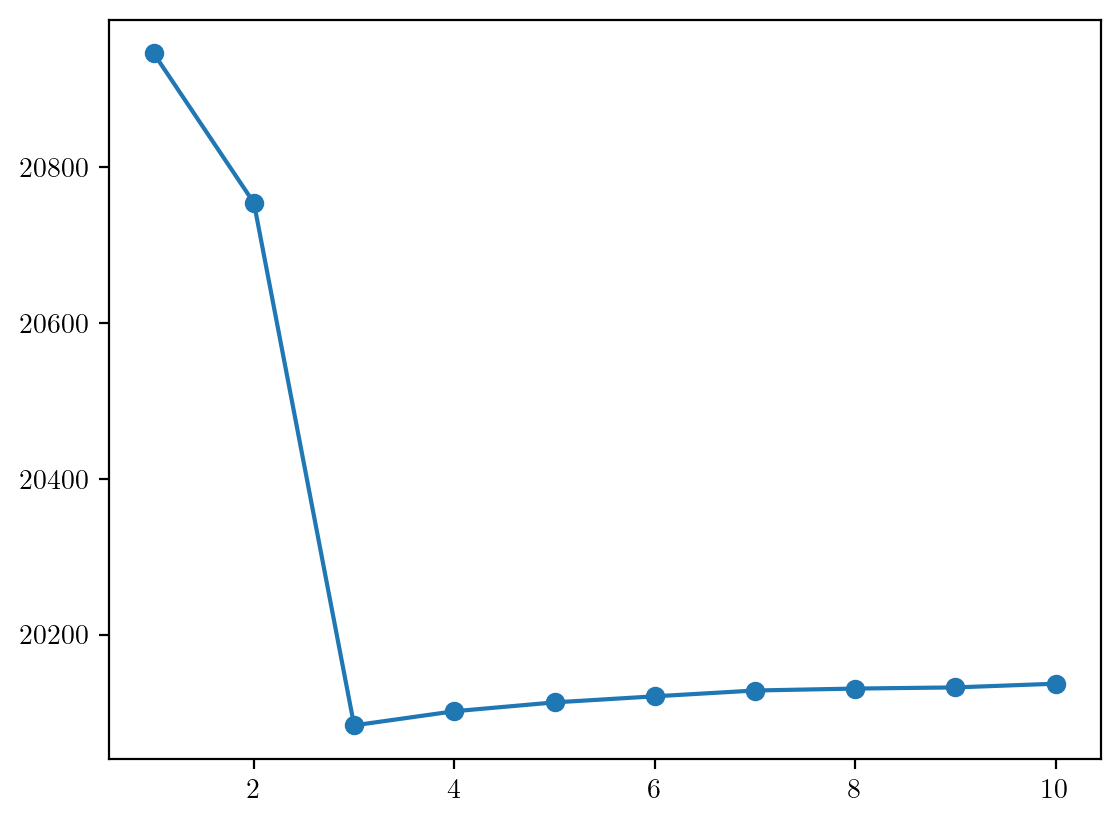

In [70]:
aic = np.zeros(10)

for n in range(1,11):

    model = GaussianMixture(n, random_state=42)
    fit = model.fit(data)
    aic[n-1] = fit.aic(data)

plt.plot(np.arange(1,11), aic, marker = 'o')


In [38]:
best = np.arange(1,11)[np.argmin(aic)]
print(best)

3



**5.** Plot the preferred solution on top of the input data. You should get a very nice fit!

In [ ]:
best_model = GaussianMixture(best, random_state=42)
best_fit = best_model.fit(data)
probs = np.exp(best_fit.score_samples(data)) # score_samples computes the log-likelihood of each sample

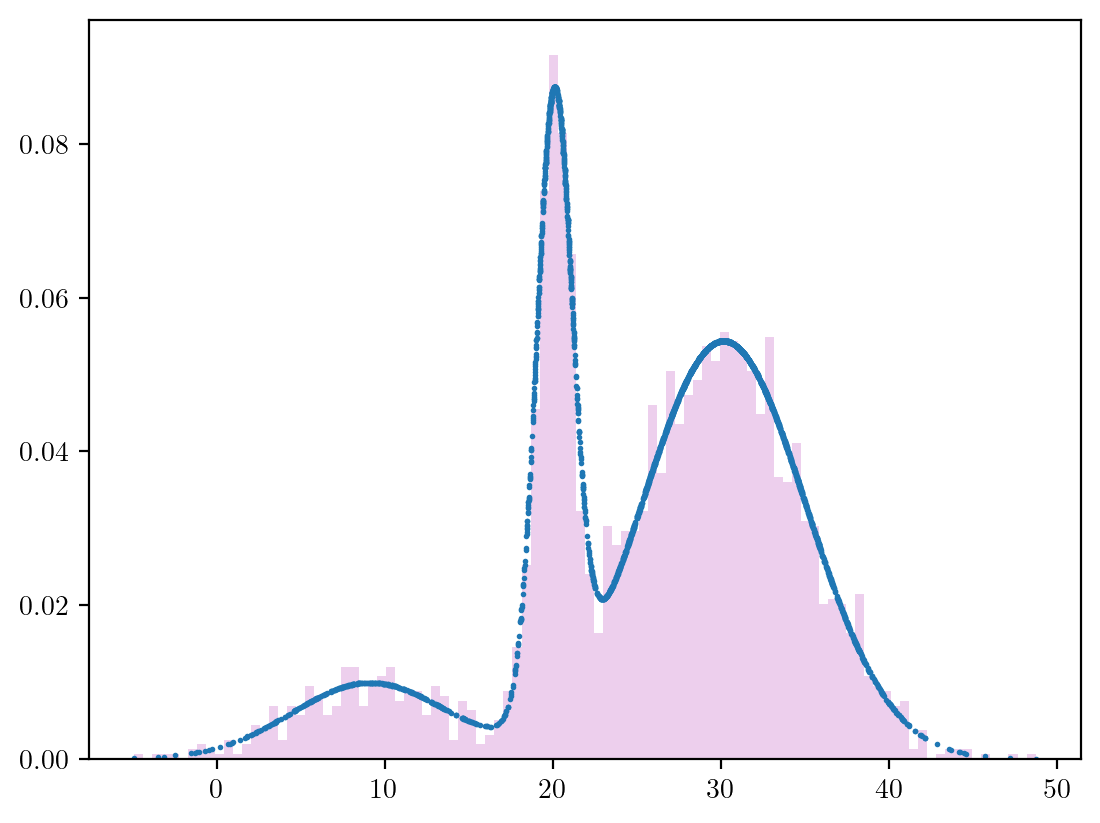

In [61]:
_ = plt.hist(data[:], bins = 100, density=True, alpha = 0.5, color='plum')
plt.scatter(data, probs, s=1.)